### Bibliotecas e Frameworks

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow import keras

2025-09-02 11:30:30.505490: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-02 11:30:30.568987: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-02 11:30:31.614997: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Questão 1

Implemente uma rede perceptron de múltiplas camadas e utilize-a para aproximar as funções abaixo.  

a. f(x) = log10(x), onde 1 ≤ x ≤ 10

b. f(x) = 10x^5 + 5x^4 + 2x^3 – 0.5x^2 + 3x + 2, onde 0 ≤ x ≤ 5

Para cada função a ser aproximada, gere um conjunto de treinamento e um conjunto de testes. 

Nesses conjuntos, cada amostra deve ser representada da seguinte forma: x é a entrada e f(x) é a saída desejada - rótulo. Treine um perceptron de múltiplas camadas para que ele aprenda a aproximar a função a partir do conjunto de treinamento, e vá testando com o conjunto de validação.  

Apresente os gráficos das funções reais vs. funções aproximadas e as curvas de erro de treinamento e validação.

#### Item a)

In [2]:
# Data

f = lambda x: np.log10(x)
X = np.linspace(1, 10, 10000).reshape(-1, 1)
y = f(X)

X_max = max(X)
X_normalized = X/X_max

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_normalized, y, test_size=0.35, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

In [3]:
# Model

input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(100, activation="relu")(input_)
hidden2 = keras.layers.Dense(100, activation="relu")(hidden1)
hidden3 = keras.layers.Dense(100, activation="relu")(hidden2)
output = keras.layers.Dense(1, dtype="float64")(hidden3)

model = keras.Model(inputs=[input_], outputs=[output])
model.compile(loss="mse", optimizer="adam", metrics=["r2_score"])
model.summary()

W0000 00:00:1756823432.145260   27593 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,501 (80.48 KB)

 Trainable params: 20,501 (80.48 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Train

history = model.fit(X_train, y_train, epochs=50, validation_data=(X_valid, y_valid))

# Prediction

y_pred = model.predict(X_test)

Epoch 1/50
 27/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2963 - r2_score: -3.3104     

2025-09-02 11:30:33.202648: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-02 11:30:33.245004: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0291 - r2_score: 0.5452 - val_loss: 0.0025 - val_r2_score: 0.9616
Epoch 2/50
 35/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0021 - r2_score: 0.9660 

2025-09-02 11:30:33.714752: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-02 11:30:33.728710: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0011 - r2_score: 0.9824 - val_loss: 3.8887e-04 - val_r2_score: 0.9941
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.1020e-04 - r2_score: 0.9967 - val_loss: 9.6431e-05 - val_r2_score: 0.9985
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.6800e-05 - r2_score: 0.9993 - val_loss: 2.7178e-05 - val_r2_score: 0.9996
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.0796e-05 - r2_score: 0.9997 - val_loss: 1.7996e-05 - val_r2_score: 0.9997
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4292e-05 - r2_score: 0.9998 - val_loss: 1.9091e-05 - val_r2_score: 0.9997
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1619e-05 - r2_score: 0.9998 - val_loss: 1.2547e-05 - val_r2_score: 0.9998
Epoch 8/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1200e-05 - r2_score: 0.9998 - val_loss: 1.1201e-05 - val_r2_score: 0.9998
Epoch 9/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.4

2025-09-02 11:30:51.637083: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-02 11:30:51.639809: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-02 11:30:51.753316: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-02 11:30:51.757141: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


<Figure size 640x480 with 0 Axes>

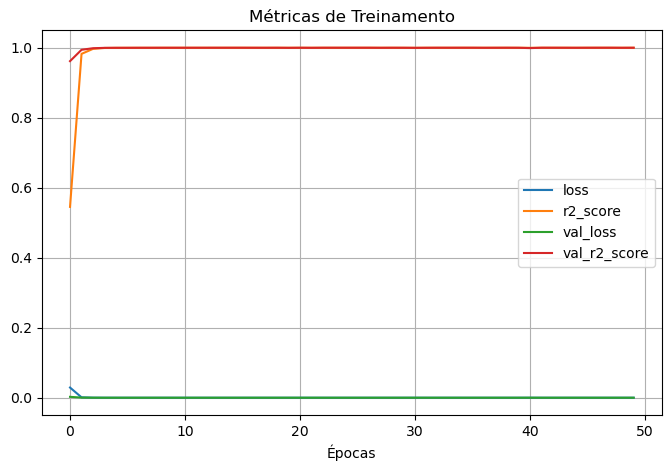

In [5]:
# Training Metrics

plt.figure()
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.title("Métricas de Treinamento")
plt.xlabel("Épocas")
plt.grid(True)
plt.show()

tf.Tensor(0.99988925, shape=(), dtype=float32)


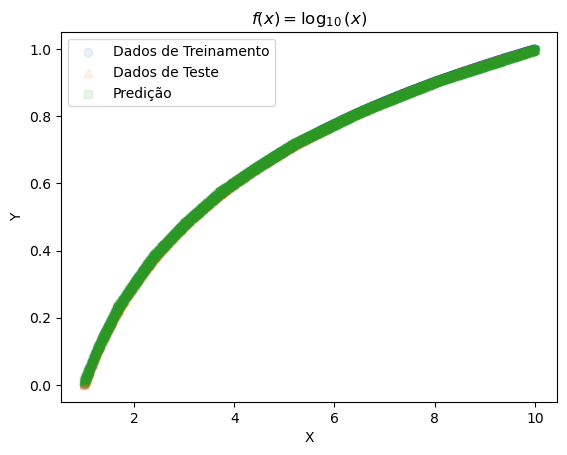

In [6]:
# Metrics

metric = keras.metrics.R2Score()
metric.update_state(y_test, y_pred)
result = metric.result()
print(result)

X_train_plot = X_train*X_max
X_test_plot = X_test*X_max

plt.figure()
plt.scatter(X_train_plot, y_train, alpha=0.1, label="Dados de Treinamento")
plt.scatter(X_test_plot, y_test, marker="^", alpha=0.1, label="Dados de Teste")
plt.scatter(X_test_plot, y_pred, marker="s", alpha=0.1, label="Predição")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title(r"$f(x) = \log _{10}(x)$");


#### Item b)

In [7]:
# Data

f = lambda x: 10*x**5 + 5*x**4 + 2*x**3 - 0.5*x**2 + 3*x + 2
X = np.linspace(0, 5, 10000).reshape(-1,1)
y = f(X)

X_max = max(X)
X_normalized = X/X_max
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_normalized, y, test_size=0.35, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

In [8]:
# Model

input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(100, activation="relu")(input_)
hidden2 = keras.layers.Dense(100, activation="relu")(hidden1)
hidden3 = keras.layers.Dense(100, activation="relu")(hidden2)
output = keras.layers.Dense(1, dtype="float64")(hidden3)

model = keras.Model(inputs=[input_], outputs=[output])
model.compile(loss="mse", optimizer="adam", metrics=["r2_score"])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,501 (80.48 KB)

 Trainable params: 20,501 (80.48 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train

history = model.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid))

# Prediction

y_pred = model.predict(X_test)

Epoch 1/100
 62/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 117644944.0000 - r2_score: -0.4779   

2025-09-02 11:30:53.412362: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-02 11:30:53.449760: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 114632496.0000 - r2_score: -0.4418 - val_loss: 95686720.0000 - val_r2_score: -0.3153
Epoch 2/100
 32/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 102326192.0000 - r2_score: -0.3021

2025-09-02 11:30:53.874878: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-02 11:30:53.885657: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 77856008.0000 - r2_score: 0.0208 - val_loss: 53911496.0000 - val_r2_score: 0.2589
Epoch 3/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55581644.0000 - r2_score: 0.3009 - val_loss: 47787276.0000 - val_r2_score: 0.3431
Epoch 4/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 48595428.0000 - r2_score: 0.3888 - val_loss: 40688844.0000 - val_r2_score: 0.4407
Epoch 5/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 40301264.0000 - r2_score: 0.4931 - val_loss: 32347044.0000 - val_r2_score: 0.5554
Epoch 6/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 31578122.0000 - r2_score: 0.6028 - val_loss: 24482624.0000 - val_r2_score: 0.6635
Epoch 7/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 23281052.0000 - r2_score: 0.7072 - val_loss: 17376300.0000 - val_r2_score: 0.7611
Epoch 8/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15954623.0000 - r2_score: 0.7993 - val_loss: 11368101.0000 - val_r2_score: 0.8437
Epoch 9/100

2025-09-02 11:31:31.831063: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-02 11:31:31.834011: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-02 11:31:31.931918: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE
2025-09-02 11:31:31.935165: W tensorflow/core/util/util.cc:163] Not handling type DT_DOUBLE


<Figure size 640x480 with 0 Axes>

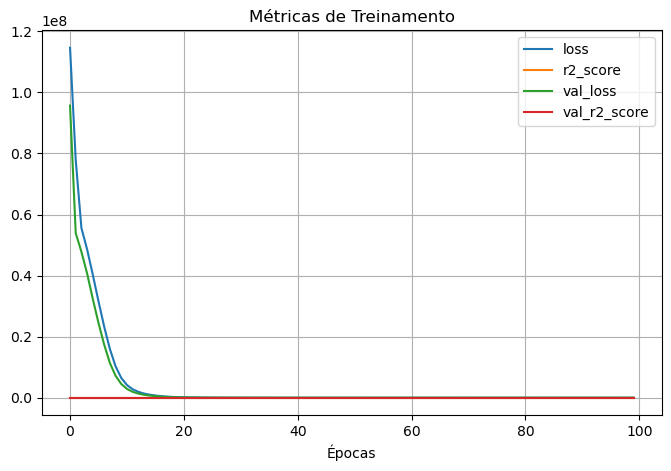

In [10]:
# Training Metrics

plt.figure()
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.title("Métricas de Treinamento")
plt.xlabel("Épocas")
plt.grid(True)

tf.Tensor(0.9999996, shape=(), dtype=float32)


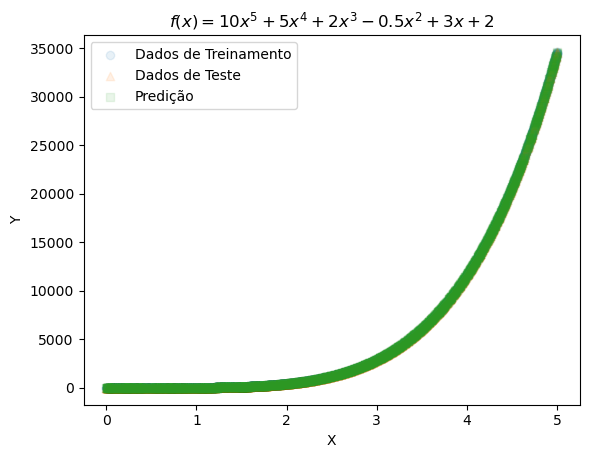

In [11]:
# Metrics

metric = keras.metrics.R2Score()
metric.update_state(y_test, y_pred)
result = metric.result()
print(result)

X_train_plot = X_train*X_max
X_test_plot = X_test*X_max

plt.figure()
plt.scatter(X_train_plot, y_train, alpha=0.1, label="Dados de Treinamento")
plt.scatter(X_test_plot, y_test, marker="^", alpha=0.1, label="Dados de Teste")
plt.scatter(X_test_plot, y_pred, marker="s", alpha=0.1, label="Predição")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title(r"$f(x) = 10x^5 + 5x^4 + 2x^3 - 0.5x^2 + 3x + 2$");